# New Section

In [34]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("results.csv")
df.head()

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral
0,1872-11-30,Scotland,England,0.0,0.0,Friendly,Glasgow,Scotland,False
1,1873-03-08,England,Scotland,4.0,2.0,Friendly,London,England,False
2,1874-03-07,Scotland,England,2.0,1.0,Friendly,Glasgow,Scotland,False
3,1875-03-06,England,Scotland,2.0,2.0,Friendly,London,England,False
4,1876-03-04,Scotland,England,3.0,0.0,Friendly,Glasgow,Scotland,False


How many matches are in the dataset?

In [35]:
df.shape


(49287, 9)

Earliest and latest year

In [36]:
df["date"] = pd.to_datetime(df["date"])

earliest = df["date"].min()
latest = df["date"].max()

earliest, latest

(Timestamp('1872-11-30 00:00:00'), Timestamp('2026-06-27 00:00:00'))

Number of unique countries

In [37]:
df["home_team"].nunique()

325

Most frequent home team

In [38]:
df["home_team"].value_counts().head()

,count
home_team,
Brazil,614
Argentina,603
Mexico,602
Germany,555
South Korea,550


Goal Analysis

Create total goals column

In [39]:
df["total_goals"] = df["home_score"] + df["away_score"]

Average Goals Per match

In [40]:
df["total_goals"].mean()

np.float64(2.93849436147516)

Highest Scoring match

In [41]:
df["total_goals"].max()
df[df["total_goals"] == df["total_goals"].max()]

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral,total_goals
25420,2001-04-11,Australia,American Samoa,31.0,0.0,FIFA World Cup qualification,Coffs Harbour,Australia,False,31.0


Are more goals at home or away?

In [42]:
df["home_score"].sum()
df["away_score"].sum()

np.float64(58192.0)

Most common total goals value



In [43]:
df["total_goals"].value_counts().head()

,count
total_goals,
2.0,10927
3.0,9724
1.0,8519
4.0,6822
5.0,4240


Match results

In [44]:
def match_result(row):
    if row["home_score"] > row["away_score"]:
        return "Home Win"
    elif row["home_score"] < row["away_score"]:
        return "Away Win"
    else:
        return "Draw"

df["result"] = df.apply(match_result, axis=1)

What percentage of the matches are home wins

In [45]:
home_wins = df["result"].value_counts(normalize=True) * 100
home_wins

,proportion
result,
Home Win,48.909449
Away Win,28.226510
Draw,22.864041


Does home advantage exist?

In [46]:
result_percentages["Home Win"] > result_percentages["Away Win"]

np.True_

Yes, home advantage exists.

This is because the percentage of home wins is higher than away wins.
From the results, home wins occur more frequently than away wins,
showing that teams perform better when playing at home.

Country with the most wins

In [47]:
wins = df[df["result"] == "Home Win"]["home_team"].value_counts()
wins.head()

,count
home_team,
Brazil,436
Argentina,404
Mexico,349
Germany,343
England,340


VISUALIZATION

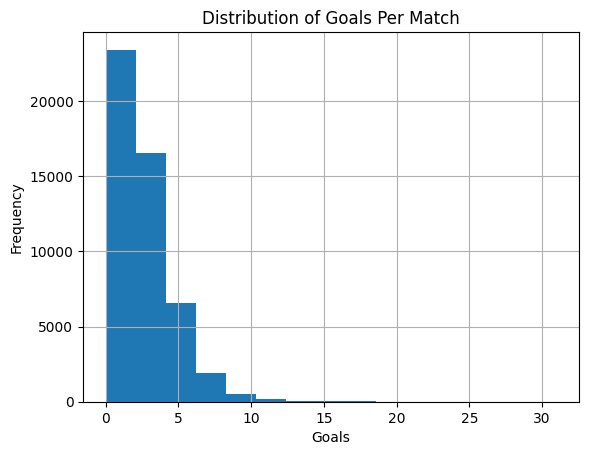

In [48]:


df["total_goals"].hist(bins=15)
plt.title("Distribution of Goals Per Match")
plt.xlabel("Goals")
plt.ylabel("Frequency")
plt.show()

Bar Chart of Match outcome

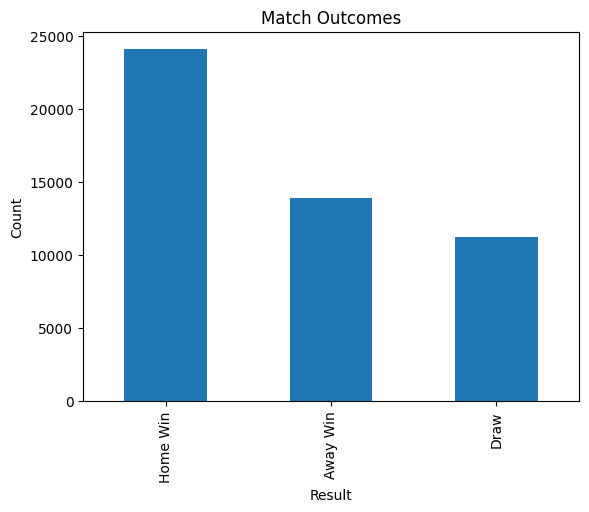

In [49]:
df["result"].value_counts().plot(kind="bar")
plt.title("Match Outcomes")
plt.xlabel("Result")
plt.ylabel("Count")
plt.show()

Top 10 teams by total wins

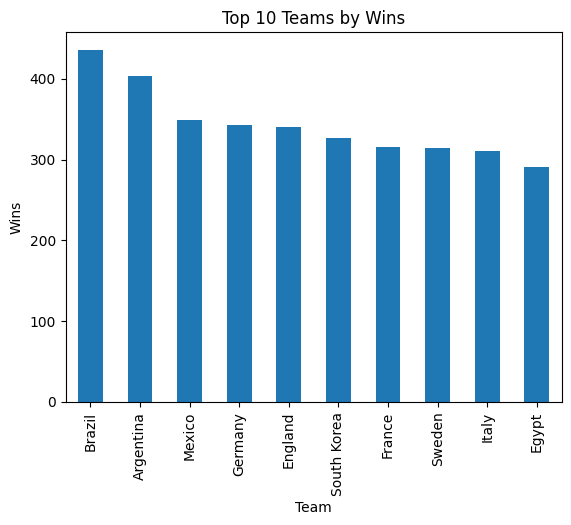

In [50]:
top_teams = df[df["result"] == "Home Win"]["home_team"].value_counts().head(10)

top_teams.plot(kind="bar")
plt.title("Top 10 Teams by Wins")
plt.xlabel("Team")
plt.ylabel("Wins")
plt.show()